<a href="https://colab.research.google.com/github/rraa2305/refactored-guide/blob/main/OLAHAN_DATA_FIX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Cek Missing Value dan Data Duplikat

In [ ]:
import pandas as pd
from google.colab import files

# 1. Upload file
print("Silakan upload file data_10k_bersih_final.csv")
uploaded = files.upload()
nama_file = list(uploaded.keys())[0]

# 2. Load data
df = pd.read_csv(nama_file, sep=None, engine="python")

print("\nBentuk data:", df.shape)
print("Kolom:", df.columns.tolist())

# 3. Cek missing value
print("\n=== Jumlah missing value per kolom ===")
print(df.isnull().sum())
print("\nTotal missing value keseluruhan:", df.isnull().sum().sum())

# 4. Cek data duplikat
print("\n=== Data duplikat ===")
print("Jumlah baris duplikat:", df.duplicated().sum())
if df.duplicated().sum() > 0:
    print("\nContoh baris duplikat:")
    print(df[df.duplicated()].head(10))

Silakan upload file data_10k_bersih_final.csv


Saving data_10k_bersih_final.csv to data_10k_bersih_final (10).csv

Bentuk data: (10000, 20)
Kolom: ['id_pelanggan', 'usia', 'status_pekerjaan', 'lama_bekerja_tahun', 'pendapatan_tahunan', 'skor_kredit', 'lama_riwayat_kredit_tahun', 'aset_tabungan', 'hutang_saat_ini', 'gagal_bayar_tercatat', 'tunggakan_2thn_terakhir', 'catatan_negatif', 'tipe_produk', 'tujuan_pinjaman', 'jumlah_pinjaman', 'suku_bunga', 'rasio_hutang_terhadap_pendapatan', 'rasio_pinjaman_terhadap_pendapatan', 'rasio_pembayaran_terhadap_pendapatan', 'status_pinjaman']

=== Jumlah missing value per kolom ===
id_pelanggan                            0
usia                                    0
status_pekerjaan                        0
lama_bekerja_tahun                      0
pendapatan_tahunan                      0
skor_kredit                             0
lama_riwayat_kredit_tahun               0
aset_tabungan                           0
hutang_saat_ini                         0
gagal_bayar_tercatat                    0
t

2. Cek Keseimbangan Data

Silakan upload file data_10k_bersih_final.csv


Saving data_10k_bersih_final.csv to data_10k_bersih_final (11).csv
Jumlah tiap kelas:
status_pinjaman
1    5505
0    4495
Name: count, dtype: int64

Persentase tiap kelas:
status_pinjaman
1    55.05
0    44.95
Name: proportion, dtype: float64


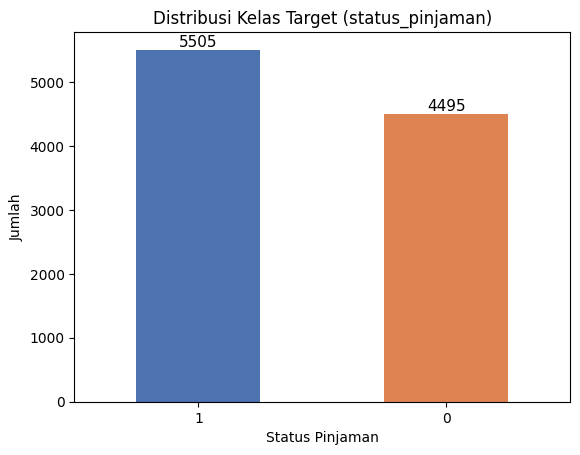

In [ ]:
import pandas as pd
from google.colab import files

# 1. Upload file
print("Silakan upload file data_10k_bersih_final.csv")
uploaded = files.upload()
nama_file = list(uploaded.keys())[0]
df = pd.read_csv(nama_file)

# 2. Cek jumlah tiap kelas
print("Jumlah tiap kelas:")
print(df["status_pinjaman"].value_counts())

# 3. Cek persentase tiap kelas
print("\nPersentase tiap kelas:")
print((df["status_pinjaman"].value_counts(normalize=True) * 100).round(2))

# 4. Visualisasi (dengan angka di atas tiap bar)
import matplotlib.pyplot as plt

counts = df["status_pinjaman"].value_counts()

ax = counts.plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Distribusi Kelas Target (status_pinjaman)")
plt.xlabel("Status Pinjaman")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)

for i, nilai in enumerate(counts):
    ax.text(i, nilai + 50, str(nilai), ha="center", fontsize=11)

plt.show()

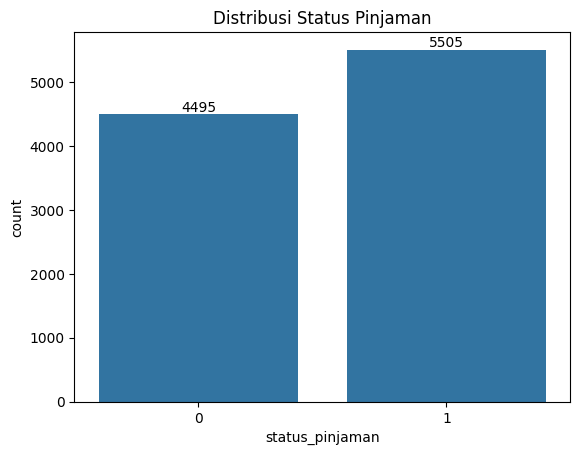

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

ax = sns.countplot(x='status_pinjaman', data=df)
ax.bar_label(ax.containers[0])
plt.title('Distribusi Status Pinjaman')
plt.show()

3. Hitung Rasio Ketidakseimbangan


In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()
nama_file = list(uploaded.keys())[0]
df = pd.read_csv(nama_file)

counts = df['status_pinjaman'].value_counts()
print("Jumlah tiap kelas:\n", counts)
print("\nImbalance ratio:", round(counts.max() / counts.min(), 2))

Saving data_10k_bersih_final.csv to data_10k_bersih_final (12).csv
Jumlah tiap kelas:
 status_pinjaman
1    5505
0    4495
Name: count, dtype: int64

Imbalance ratio: 1.22


4. Heatmap Korelasi (Sebelum Fitur dihapus)

Silakan upload file data_10k_bersih_final.csv


Saving data_10k_bersih_final.csv to data_10k_bersih_final (13).csv


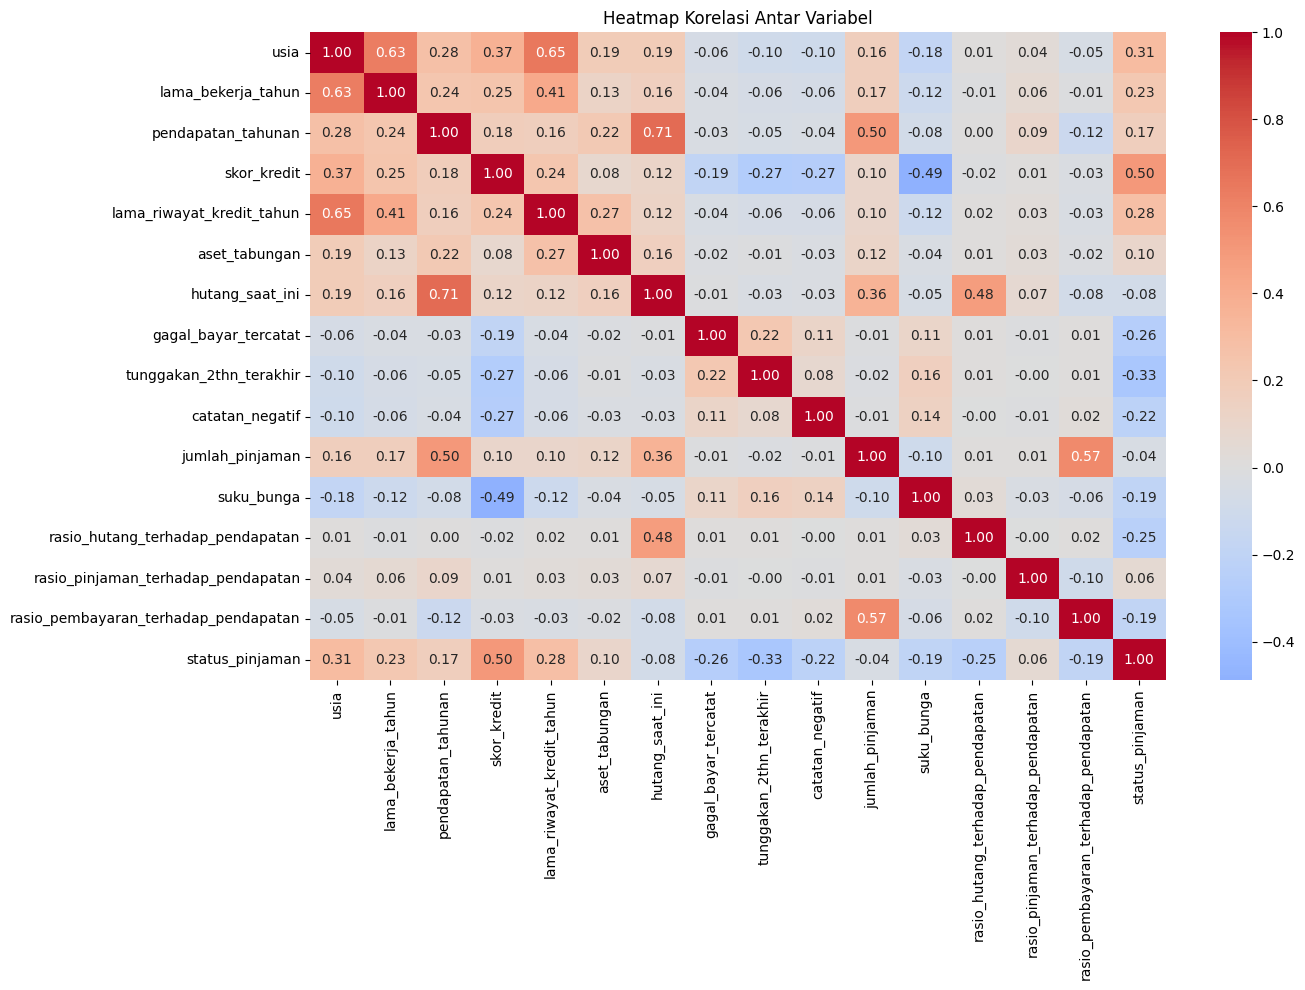

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# 1. Upload file
print("Silakan upload file data_10k_bersih_final.csv")
uploaded = files.upload()
nama_file = list(uploaded.keys())[0]
df = pd.read_csv(nama_file)

# 2. Hitung korelasi (semua kolom numerik, id_pelanggan otomatis terlewat karena teks)
korelasi = df.select_dtypes(include="number").corr()

# 3. Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(korelasi, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Heatmap Korelasi Antar Variabel")
plt.tight_layout()
plt.show()

5. Hapus Kolom yang irelevan

In [ ]:
import pandas as pd
from google.colab import files

# 1. Upload file data_10k_bersih_final.csv (kalau df belum ada di memori)
print("Silakan upload file data_10k_bersih_final.csv")
uploaded = files.upload()
nama_file = list(uploaded.keys())[0]
df = pd.read_csv(nama_file)

# 2. Hapus 3 kolom yang sudah disepakati
df = df.drop(columns=["hutang_saat_ini", "jumlah_pinjaman", "lama_bekerja_tahun"])

print("Jumlah kolom setelah dihapus:", df.shape[1])
print(df.columns.tolist())

# 3. Simpan jadi file baru (TIDAK menimpa data_10k_bersih_final.csv yang asli)
df.to_csv("data_10k_fitur_terpilih.csv", index=False)

# 4. Download ke komputer kamu
files.download("data_10k_fitur_terpilih.csv")

print("\nSelesai! File tersimpan sebagai data_10k_fitur_terpilih.csv")

Silakan upload file data_10k_bersih_final.csv


Saving data_10k_bersih_final.csv to data_10k_bersih_final (14).csv
Jumlah kolom setelah dihapus: 17
['id_pelanggan', 'usia', 'status_pekerjaan', 'pendapatan_tahunan', 'skor_kredit', 'lama_riwayat_kredit_tahun', 'aset_tabungan', 'gagal_bayar_tercatat', 'tunggakan_2thn_terakhir', 'catatan_negatif', 'tipe_produk', 'tujuan_pinjaman', 'suku_bunga', 'rasio_hutang_terhadap_pendapatan', 'rasio_pinjaman_terhadap_pendapatan', 'rasio_pembayaran_terhadap_pendapatan', 'status_pinjaman']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Selesai! File tersimpan sebagai data_10k_fitur_terpilih.csv


Mulai dari sini masih kode lama, tapi output nya sudah beda karena file ku yang sa pake sudah beda (Hikmat)

Nanti kalau ko baca ini, ko cek drive ada namanya "data10k bersih final" dan "data 15 kolom" atau apalah itu, itu versi yang sudah sa hapus kolom yang nda terlalu berhubungan. sa mo tidurmi

BTW kalau ada yang ko mau suruh sa ubah, jas tel mi brok tapi kayaknya sa bakal slowresp karena aku nak tido wokwowkowk

catatan : setelah ini bagiannya sara atau yusril pernah sa nda tau, sa nda mengerti juga yang bawah bawah ini sa takut hapus atau ubah yang ytta aja ya ygy.✌️

In [ ]:
import pandas as pd

# Membaca data yang sudah dipilih fiturnya
df = pd.read_csv('data_10k_fitur_terpilih.csv')

# 1. Pilih kolom kategorikal yang ingin di-encode
kolom_kategorikal = ['status_pekerjaan', 'tipe_produk', 'tujuan_pinjaman']

# 2. Terapkan One-Hot Encoding (drop_first=True untuk menghindari multicollinearity)
df_encoded = pd.get_dummies(df, columns=kolom_kategorikal, drop_first=True, dtype=int)

# 3. Cek hasil kolom baru
print("Bentuk dataset setelah encoding:", df_encoded.shape)
print("\nContoh 5 baris pertama:")
df_encoded.head()

Bentuk dataset setelah encoding: (10000, 23)

Contoh 5 baris pertama:


,id_pelanggan,usia,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,suku_bunga,...,status_pinjaman,status_pekerjaan_Mahasiswa,status_pekerjaan_Wiraswasta,tipe_produk_Kredit Berjalan,tipe_produk_Pinjaman Pribadi,tujuan_pinjaman_Konsolidasi Hutang,tujuan_pinjaman_Medis,tujuan_pinjaman_Pendidikan,tujuan_pinjaman_Pribadi,tujuan_pinjaman_Renovasi Rumah
0,CUST100000,23,38688,626,3.5,354,0,0,0,14.66,...,0,0,0,0,1,0,0,0,1,0
1,CUST100001,33,15000,674,14.6,131,0,0,0,17.32,...,1,0,0,0,0,0,0,1,0,0
2,CUST100002,53,66688,774,4.5,129,0,0,0,8.63,...,1,0,0,0,1,0,0,1,0,0
3,CUST100003,19,41693,611,0.1,3,0,0,0,20.76,...,0,0,0,0,0,0,0,0,0,0
4,CUST100004,22,70441,564,1.7,42,0,0,0,21.80,...,1,0,1,0,0,0,0,1,0,0


In [ ]:
from sklearn.model_selection import train_test_split

# Hapus id_pelanggan dan target
X = df_encoded.drop(columns=['id_pelanggan', 'status_pinjaman'])
y = df_encoded['status_pinjaman']

# Split data 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (8000, 21)
X_test shape: (2000, 21)


In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Tentukan daftar kolom numerik yang ingin di-scale
 #(tanpa lama_bekerja_tahun karena sudah dihapus)
kolom_numerik = [
    'usia',
    'skor_kredit',
    'lama_riwayat_kredit_tahun',
    'gagal_bayar_tercatat',
    'tunggakan_2thn_terakhir',
    'catatan_negatif',
    'rasio_hutang_terhadap_pendapatan',
    'rasio_pinjaman_terhadap_pendapatan',
    'rasio_pembayaran_terhadap_pendapatan'
]

# 2. Inisialisasi Scaler
scaler = StandardScaler()

# 3. Buat copy dari X_train dan X_test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# 4. Fit & Transform HANYA pada kolom numerik di X_train
X_train_scaled[kolom_numerik] = scaler.fit_transform(X_train[kolom_numerik])

# 5. Transform HANYA pada kolom numerik di X_test (tanpa fit)
X_test_scaled[kolom_numerik] = scaler.transform(X_test[kolom_numerik])

# Cek hasil (kolom kategorikal/dummy tetap bernilai 0 dan 1)
X_train_scaled.head()

,usia,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,suku_bunga,rasio_hutang_terhadap_pendapatan,...,rasio_pembayaran_terhadap_pendapatan,status_pekerjaan_Mahasiswa,status_pekerjaan_Wiraswasta,tipe_produk_Kredit Berjalan,tipe_produk_Pinjaman Pribadi,tujuan_pinjaman_Konsolidasi Hutang,tujuan_pinjaman_Medis,tujuan_pinjaman_Pendidikan,tujuan_pinjaman_Pribadi,tujuan_pinjaman_Renovasi Rumah
4454,0.192785,198104,1.428985,-0.627771,971,-0.233016,-0.658676,-0.355246,9.71,0.939243,...,-0.529292,0,1,0,1,0,0,0,0,0
7938,1.188098,26432,0.621716,-0.848802,193,-0.233016,-0.658676,-0.355246,11.52,-0.571557,...,-1.284332,1,0,0,1,0,1,0,0,0
6626,-0.802528,15000,-1.349885,-0.710658,846,-0.233016,0.513606,2.034968,15.23,1.810858,...,0.883591,0,0,0,1,0,0,0,0,0
7265,-0.621562,23368,-0.961774,-0.171895,911,-0.233016,0.513606,-0.355246,21.16,1.973559,...,0.268499,0,1,0,0,0,0,0,0,1
9051,1.188098,185143,1.599754,0.629343,832,-0.233016,-0.658676,2.034968,16.46,-0.844663,...,-1.028673,0,1,0,0,1,0,0,0,0


In [ ]:
# 1. Pastikan target (status_pinjaman) dipisahkan dari fitur
X_train_final = X_train_scaled.drop(columns=['status_pinjaman'], errors='ignore')
X_test_final = X_test_scaled.drop(columns=['status_pinjaman'], errors='ignore')

# Target (y) diambil dari hasil split sebelumnya
# y_train dan y_test sudah otomatis siap digunaan

# 2. Cek bentuk data (Shape) untuk memastikan jumlah kolom sudah cocok
print("Jumlah Fitur Data Latih (X_train_final) :", X_train_final.shape)
print("Jumlah Target Data Latih (y_train)       :", y_train.shape)
print("Jumlah Fitur Data Uji   (X_test_final)  :", X_test_final.shape)
print("Jumlah Target Data Uji   (y_test)        :", y_test.shape)

Jumlah Fitur Data Latih (X_train_final) : (8000, 21)
Jumlah Target Data Latih (y_train)       : (8000,)
Jumlah Fitur Data Uji   (X_test_final)  : (2000, 21)
Jumlah Target Data Uji   (y_test)        : (2000,)


=== EVALUASI MODEL RANDOM FOREST ===
Akurasi Model: 0.882

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87       899
           1       0.88      0.90      0.89      1101

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000



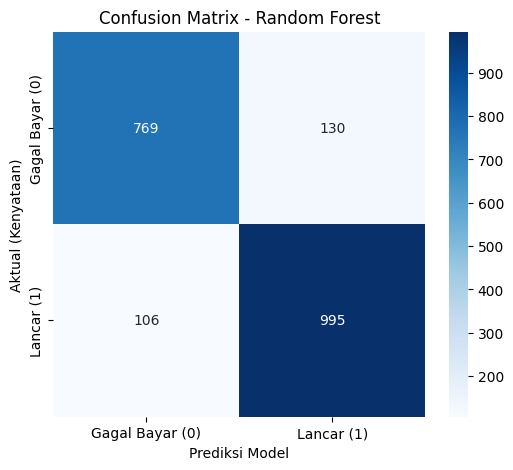

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Inisialisasi Model Random Forest
rf_model = RandomForestClassifier(random_state=42)

# 2. Train Model dengan Data Latih
rf_model.fit(X_train_final, y_train)

# 3. Prediksi ke Data Uji
y_pred_rf = rf_model.predict(X_test_final)

# 4. Evaluasi Akurasi & Classification Report
print("=== EVALUASI MODEL RANDOM FOREST ===")
print("Akurasi Model:", accuracy_score(y_test, y_pred_rf))
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred_rf))

# 5. Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Gagal Bayar (0)', 'Lancar (1)'],
            yticklabels=['Gagal Bayar (0)', 'Lancar (1)'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Prediksi Model')
plt.ylabel('Aktual (Kenyataan)')
plt.show()

=== EVALUASI MODEL XGBOOST ===
Akurasi Model: 0.8975

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.90      0.86      0.88       899
           1       0.89      0.92      0.91      1101

    accuracy                           0.90      2000
   macro avg       0.90      0.89      0.90      2000
weighted avg       0.90      0.90      0.90      2000



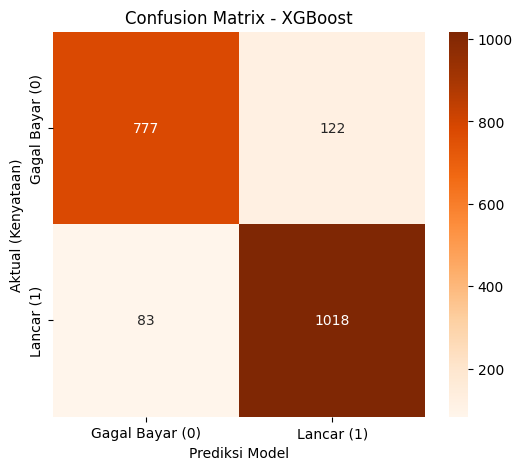

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Inisialisasi Model XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# 2. Train Model dengan Data Latih
xgb_model.fit(X_train_final, y_train)

# 3. Prediksi ke Data Uji
y_pred_xgb = xgb_model.predict(X_test_final)

# 4. Evaluasi Akurasi & Classification Report
print("=== EVALUASI MODEL XGBOOST ===")
print("Akurasi Model:", accuracy_score(y_test, y_pred_xgb))
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred_xgb))

# 5. Visualisasi Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Gagal Bayar (0)', 'Lancar (1)'],
            yticklabels=['Gagal Bayar (0)', 'Lancar (1)'])
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Prediksi Model')
plt.ylabel('Aktual (Kenyataan)')
plt.show()

/tmp/ipykernel_1551/2279626391.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance_rf, palette='Blues_r')


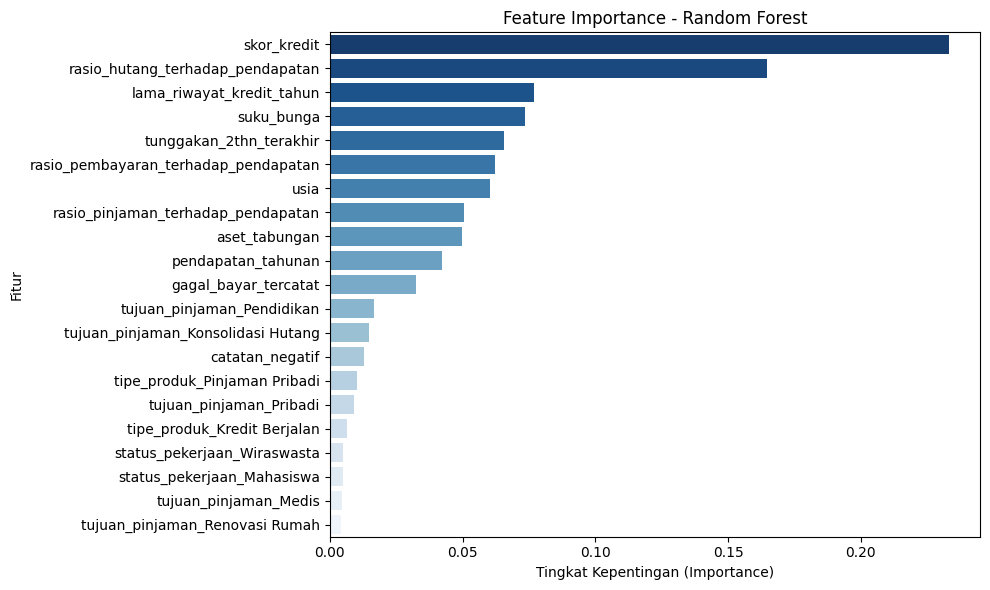

=== TOP 10 FITUR TERPENTING (RANDOM FOREST) ===
                             Feature  Importance
                         skor_kredit    0.233189
    rasio_hutang_terhadap_pendapatan    0.164468
           lama_riwayat_kredit_tahun    0.076771
                          suku_bunga    0.073527
             tunggakan_2thn_terakhir    0.065558
rasio_pembayaran_terhadap_pendapatan    0.062256
                                usia    0.060356
  rasio_pinjaman_terhadap_pendapatan    0.050608
                       aset_tabungan    0.049912
                  pendapatan_tahunan    0.042186


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mengambil nilai importance dari model Random Forest
importances_rf = rf_model.feature_importances_
feature_names = X_train_final.columns

# 2. Membuat DataFrame dan mengurutkan dari yang paling penting
df_importance_rf = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_rf
}).sort_values(by='Importance', ascending=False)

# 3. Visualisasi dengan Barplot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance_rf, palette='Blues_r')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Tingkat Kepentingan (Importance)')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

# Menampilkan 10 Fitur Teratas
print("=== TOP 10 FITUR TERPENTING (RANDOM FOREST) ===")
print(df_importance_rf.head(10).to_string(index=False))

### 6. Inference dengan Input Manual

Gunakan formulir di bawah ini untuk memasukkan data pelanggan secara manual dan memprediksi apakah status pinjamannya akan **Lancar (1)** atau **Gagal Bayar (0)**.

In [ ]:
# @title
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- 0. Bangun ulang model kalau belum ada di memori ---
try:
    _ = X_train.columns
    _ = scaler
    _ = xgb_model
except NameError:
    print("Membangun ulang model dan scaler dari data_10k_fitur_terpilih.csv...")
    df_temp = pd.read_csv('data_10k_fitur_terpilih.csv')
    kolom_kategorikal = ['status_pekerjaan', 'tipe_produk', 'tujuan_pinjaman']
    df_encoded_temp = pd.get_dummies(df_temp, columns=kolom_kategorikal, drop_first=True, dtype=int)

    X_temp = df_encoded_temp.drop(columns=['id_pelanggan', 'status_pinjaman'])
    y_temp = df_encoded_temp['status_pinjaman']

    X_train, X_test, y_train, y_test = train_test_split(
        X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
    )

    numerical_cols = [
        'usia', 'skor_kredit', 'lama_riwayat_kredit_tahun',
        'gagal_bayar_tercatat', 'tunggakan_2thn_terakhir', 'catatan_negatif',
        'rasio_hutang_terhadap_pendapatan', 'rasio_pinjaman_terhadap_pendapatan',
        'rasio_pembayaran_terhadap_pendapatan'
    ]

    scaler = StandardScaler()
    X_train_scaled_temp = X_train.copy()
    X_train_scaled_temp[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

    xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
    xgb_model.fit(X_train_scaled_temp, y_train)
    print("Model berhasil dibangun ulang!")

numerical_cols = [
    'usia', 'skor_kredit', 'lama_riwayat_kredit_tahun',
    'gagal_bayar_tercatat', 'tunggakan_2thn_terakhir', 'catatan_negatif',
    'rasio_hutang_terhadap_pendapatan', 'rasio_pinjaman_terhadap_pendapatan',
    'rasio_pembayaran_terhadap_pendapatan'
]

# --- 1. Definisi Komponen Widget dengan Gaya yang Rapi ---
style = {'description_width': '180px'}
layout = widgets.Layout(width='400px')

header = widgets.HTML(
    value="<h2 style='color:#ffffff; font-family:sans-serif; text-align:center;'>🏦 PANEL KONTROL PREDIKSI STATUS PINJAMAN 🏦</h2>"
          "<p style='color:#7f8c8d; text-align:center; font-style:italic;'>Sesuaikan parameter nasabah di bawah ini untuk menguji kelayakan pinjaman</p>"
)

# Data Pelanggan & Profil Finansial
usia_widget = widgets.IntText(value=38, description='Usia (tahun):', style=style, layout=layout)
pekerjaan_widget = widgets.Dropdown(options=['Karyawan', 'Wiraswasta', 'Mahasiswa', 'Pengangguran'], value='Karyawan', description='Status Pekerjaan:', style=style, layout=layout)
produk_widget = widgets.Dropdown(options=['Kredit Berjalan', 'Pinjaman Pribadi', 'KPR', 'Kredit Kendaraan'], value='Kredit Kendaraan', description='Tipe Produk:', style=style, layout=layout)
tujuan_widget = widgets.Dropdown(options=['Pendidikan', 'Konsolidasi Hutang', 'Medis', 'Pribadi', 'Renovasi Rumah', 'Lainnya'], value='Pribadi', description='Tujuan Pinjaman:', style=style, layout=layout)
pendapatan_widget = widgets.IntText(value=6000000, description='Pendapatan/Thn (Rp):', style=style, layout=layout)
skor_widget = widgets.IntText(value=750, description='Skor Kredit:', style=style, layout=layout)
riwayat_widget = widgets.FloatText(value=8.0, description='Lama Riwayat Kredit (thn):', style=style, layout=layout)
aset_widget = widgets.IntText(value=15000000, description='Aset Tabungan (Rp):', style=style, layout=layout)
bunga_widget = widgets.FloatText(value=8.0, description='Suku Bunga (%):', style=style, layout=layout)

# Riwayat & Faktor Risiko
gagal_bayar_widget = widgets.Checkbox(value=False, description='Gagal Bayar Tercatat', style=style)
tunggakan_widget = widgets.IntText(value=0, description='Tunggakan 2 Thn Terakhir:', style=style, layout=layout)
catatan_widget = widgets.IntText(value=0, description='Catatan Negatif:', style=style, layout=layout)
rasio_hutang_widget = widgets.FloatText(value=0.2, description='Rasio Hutang/Pendapatan:', style=style, layout=layout)
rasio_pinjaman_widget = widgets.FloatText(value=0.1, description='Rasio Pinjaman/Pendapatan:', style=style, layout=layout)
rasio_bayar_widget = widgets.FloatText(value=0.2, description='Rasio Pembayaran/Pendapatan:', style=style, layout=layout)

# Tombol Trigger Prediksi
predict_button = widgets.Button(
    description='ANALISIS STATUS PINJAMAN',
    button_style='info',
    tooltip='Klik untuk memulai prediksi',
    layout=widgets.Layout(width='100%', height='45px', margin='20px 0px 0px 0px')
)

output_area = widgets.Output()

# --- 2. Fungsi Logika Preprocessing & Prediksi ---
def run_prediction(b):
    with output_area:
        clear_output()

        input_data = {
            'usia': usia_widget.value,
            'pendapatan_tahunan': pendapatan_widget.value,
            'skor_kredit': skor_widget.value,
            'lama_riwayat_kredit_tahun': riwayat_widget.value,
            'aset_tabungan': aset_widget.value,
            'gagal_bayar_tercatat': int(gagal_bayar_widget.value),
            'tunggakan_2thn_terakhir': tunggakan_widget.value,
            'catatan_negatif': catatan_widget.value,
            'suku_bunga': bunga_widget.value,
            'rasio_hutang_terhadap_pendapatan': rasio_hutang_widget.value,
            'rasio_pinjaman_terhadap_pendapatan': rasio_pinjaman_widget.value,
            'rasio_pembayaran_terhadap_pendapatan': rasio_bayar_widget.value,
            'status_pekerjaan': pekerjaan_widget.value,
            'tipe_produk': produk_widget.value,
            'tujuan_pinjaman': tujuan_widget.value,
        }

        df_input = pd.DataFrame([input_data])

        # One-Hot Encoding
        kolom_kategorikal = ['status_pekerjaan', 'tipe_produk', 'tujuan_pinjaman']
        df_input_encoded = pd.get_dummies(df_input, columns=kolom_kategorikal, drop_first=True)
        for col in X_train.columns:
            if col not in df_input_encoded.columns:
                df_input_encoded[col] = 0
        df_input_encoded = df_input_encoded[X_train.columns]

        # Scaling
        df_input_scaled = df_input_encoded.copy()
        df_input_scaled[numerical_cols] = scaler.transform(df_input_encoded[numerical_cols])

        # Prediksi Model
        pred = xgb_model.predict(df_input_scaled)[0]
        prob = xgb_model.predict_proba(df_input_scaled)[0][1]

        # Render Hasil Berbentuk Desain HTML
        if pred == 1:
            alert_color = '#2ecc71'
            status_text = '✅ STATUS PINJAMAN: DITERIMA ✅'
            desc_text = f"Sistem menunjukkan kelayakan pinjaman yang baik dengan tingkat keyakinan <b>{prob * 100:.2f}%</b>."
        else:
            alert_color = '#e74c3c'
            status_text = '🚨 STATUS PINJAMAN: DITOLAK 🚨'
            desc_text = f"Sistem mendeteksi tingkat risiko tinggi gagal bayar dengan tingkat keyakinan <b>{(1 - prob) * 100:.2f}%</b>. Perlu peninjauan lebih lanjut!"

        display(widgets.HTML(
            value=f"""
            <div style='border: 2px solid {alert_color}; border-radius: 8px; padding: 15px; margin-top: 15px; background-color: {alert_color}10;'>
                <h3 style='color: {alert_color}; margin-top: 0; font-family: sans-serif; text-align: center;'>{status_text}</h3>
                <p style='color: #ffffff; font-family: sans-serif; font-size: 14px; text-align: center;'>{desc_text}</p>
            </div>
            """
        ))

predict_button.on_click(run_prediction)

# --- 3. Pengelompokan & Layouting Panel ---
left_column = widgets.VBox([
    widgets.HTML("<h4>👤 Data Pelanggan & Profil Finansial</h4>"),
    usia_widget, pekerjaan_widget, produk_widget, tujuan_widget,
    pendapatan_widget, skor_widget, riwayat_widget, aset_widget, bunga_widget
])

right_column = widgets.VBox([
    widgets.HTML("<h4>⚠️ Riwayat & Faktor Risiko</h4>"),
    gagal_bayar_widget, tunggakan_widget, catatan_widget,
    rasio_hutang_widget, rasio_pinjaman_widget, rasio_bayar_widget
], layout=widgets.Layout(margin='0px 0px 0px 40px'))

form_container = widgets.HBox([left_column, right_column])
main_dashboard = widgets.VBox([header, form_container, predict_button, output_area],
                              layout=widgets.Layout(padding='20px', border='1px solid #ddd', border_radius='10px', background_color='#fafafa'))

# Tampilkan Panel Kontrol Utama
display(main_dashboard)

In [ ]:
#@title Formulir Input Data Pelanggan { run: "auto" }

# 1. Definisikan Input Form
usia = 38 #@param {type:"integer"}
status_pekerjaan = "Karyawan" #@param ["Karyawan", "Wiraswasta", "Mahasiswa", "Pengangguran"]
tipe_produk = "Kredit Kendaraan" #@param ["Kredit Berjalan", "Pinjaman Pribadi", "KPR", "Kredit Kendaraan"]
tujuan_pinjaman = "Pribadi" #@param ["Pendidikan", "Konsolidasi Hutang", "Medis", "Pribadi", "Renovasi Rumah", "Lainnya"]
pendapatan_tahunan = 6000000 #@param {type:"number"}
skor_kredit = 750 #@param {type:"integer"}
lama_riwayat_kredit_tahun = 8 #@param {type:"number"}
aset_tabungan = 15000000 #@param {type:"number"}
gagal_bayar_tercatat = 0 #@param [0, 1] {type:"raw"}
tunggakan_2thn_terakhir = 0 #@param {type:"integer"}
catatan_negatif = 0 #@param {type:"integer"}
suku_bunga = 8 #@param {type:"number"}
rasio_hutang_terhadap_pendapatan = 0.2 #@param {type:"number"}
rasio_pinjaman_terhadap_pendapatan = 0.1 #@param {type:"number"}
rasio_pembayaran_terhadap_pendapatan = 0.2 #@param {type:"number"}

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Memastikan variabel-variabel penting tersedia, jika tidak, kita bangun ulang secara otomatis
try:
    _ = X_train.columns
    _ = scaler
    _ = xgb_model
except NameError:
    print("Membangun ulang model dan scaler secara otomatis dari data_10k_fitur_terpilih.csv...")
    try:
        df_temp = pd.read_csv('data_10k_fitur_terpilih.csv')
        kolom_kategorikal = ['status_pekerjaan', 'tipe_produk', 'tujuan_pinjaman']
        df_encoded_temp = pd.get_dummies(df_temp, columns=kolom_kategorikal, drop_first=True, dtype=int)

        X_temp = df_encoded_temp.drop(columns=['id_pelanggan', 'status_pinjaman'])
        y_temp = df_encoded_temp['status_pinjaman']

        X_train, X_test, y_train, y_test = train_test_split(
            X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
        )

        kolom_numerik = [
            'usia', 'skor_kredit', 'lama_riwayat_kredit_tahun',
            'gagal_bayar_tercatat', 'tunggakan_2thn_terakhir', 'catatan_negatif',
            'rasio_hutang_terhadap_pendapatan', 'rasio_pinjaman_terhadap_pendapatan',
            'rasio_pembayaran_terhadap_pendapatan'
        ]

        scaler = StandardScaler()
        X_train_scaled_temp = X_train.copy()
        X_train_scaled_temp[kolom_numerik] = scaler.fit_transform(X_train[kolom_numerik])

        xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
        xgb_model.fit(X_train_scaled_temp, y_train)
        print("Model berhasil dibangun ulang!")
    except Exception as e:
        print("Gagal membangun ulang model secara otomatis. Pastikan file 'data_10k_fitur_terpilih.csv' tersedia dan sel training sebelumnya telah dijalankan.")
        print("Error:", e)

# Definisikan kolom_numerik jika belum ada
kolom_numerik = [
    'usia',
    'skor_kredit',
    'lama_riwayat_kredit_tahun',
    'gagal_bayar_tercatat',
    'tunggakan_2thn_terakhir',
    'catatan_negatif',
    'rasio_hutang_terhadap_pendapatan',
    'rasio_pinjaman_terhadap_pendapatan',
    'rasio_pembayaran_terhadap_pendapatan'
]

# 2. Buat DataFrame dari input
input_data = pd.DataFrame([{
    'usia': usia,
    'pendapatan_tahunan': pendapatan_tahunan,
    'skor_kredit': skor_kredit,
    'lama_riwayat_kredit_tahun': lama_riwayat_kredit_tahun,
    'aset_tabungan': aset_tabungan,
    'gagal_bayar_tercatat': gagal_bayar_tercatat,
    'tunggakan_2thn_terakhir': tunggakan_2thn_terakhir,
    'catatan_negatif': catatan_negatif,
    'suku_bunga': suku_bunga,
    'rasio_hutang_terhadap_pendapatan': rasio_hutang_terhadap_pendapatan,
    'rasio_pinjaman_terhadap_pendapatan': rasio_pinjaman_terhadap_pendapatan,
    'rasio_pembayaran_terhadap_pendapatan': rasio_pembayaran_terhadap_pendapatan,
    'status_pekerjaan': status_pekerjaan,
    'tipe_produk': tipe_produk,
    'tujuan_pinjaman': tujuan_pinjaman
}])

# 3. One-Hot Encoding sesuai dengan format training
# Buat semua kolom dummy yang ada di X_train dengan nilai awal 0
for col in X_train.columns:
    if col not in input_data.columns:
        input_data[col] = 0

# Isi nilai dummy berdasarkan input manual
if f"status_pekerjaan_{status_pekerjaan}" in input_data.columns:
    input_data[f"status_pekerjaan_{status_pekerjaan}"] = 1
if f"tipe_produk_{tipe_produk}" in input_data.columns:
    input_data[f"tipe_produk_{tipe_produk}"] = 1
if f"tujuan_pinjaman_{tujuan_pinjaman}" in input_data.columns:
    input_data[f"tujuan_pinjaman_{tujuan_pinjaman}"] = 1

# 4. Susun urutan kolom agar persis sama dengan X_train
input_data = input_data[X_train.columns]

# 5. Lakukan Scaling pada kolom numerik
input_scaled = input_data.copy()
input_scaled[kolom_numerik] = scaler.transform(input_data[kolom_numerik])

# 6. Prediksi menggunakan XGBoost (Model dengan akurasi tertinggi)
try:
    prediksi = xgb_model.predict(input_scaled)[0]
    probabilitas = xgb_model.predict_proba(input_scaled)[0]

    print("\n=== HASIL PREDIKSI (XGBOOST) ===")
    if prediksi == 1:
        print(f"Status Pinjaman: LANCAR (1) dengan probabilitas {probabilitas[1]*100:.2f}%")
    else:
        print(f"Status Pinjaman: GAGAL BAYAR (0) dengan probabilitas {probabilitas[0]*100:.2f}%")
except NameError:
    print("Silakan jalankan sel training model XGBoost terlebih dahulu!")


=== HASIL PREDIKSI (XGBOOST) ===
Status Pinjaman: LANCAR (1) dengan probabilitas 98.90%
